In [40]:
import pandas as pd
import numpy as np

# Load the original Lending Club dataset
df = pd.read_pickle("../data/raw/dataset.pkl")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (252971, 21)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,5000.0,36,10.65,162.87,B,B2,10+,RENT,24000.0,Verified,...,27.65,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,171.62,Fully Paid
1,2500.0,60,15.27,59.83,C,C4,<1,RENT,30000.0,Source Verified,...,1.00,0.0,5.0,3.0,0.0,1687.0,9.4,4.0,119.66,Charged Off
2,2400.0,36,15.96,84.33,C,C5,10+,RENT,12252.0,Not Verified,...,8.72,0.0,2.0,2.0,0.0,2956.0,98.5,10.0,649.91,Fully Paid
3,10000.0,36,13.49,339.31,C,C1,10+,RENT,49200.0,Source Verified,...,20.00,0.0,1.0,10.0,0.0,5598.0,21.0,37.0,357.48,Fully Paid
5,5000.0,36,7.90,156.46,A,A4,3,RENT,36000.0,Source Verified,...,11.20,0.0,3.0,9.0,0.0,7963.0,28.3,12.0,161.03,Fully Paid


In [41]:
# Display all columns with their data types

print("Total columns:", len(df.columns))
print()

for i in range(len(df.columns)):
    print(f"{i+1:2}. {df.columns[i]:25} -> {df.dtypes.iloc[i]}")

Total columns: 21

 1. loan_amnt                 -> float64
 2. term                      -> int64
 3. int_rate                  -> float64
 4. installment               -> float64
 5. grade                     -> object
 6. sub_grade                 -> object
 7. emp_length                -> object
 8. home_ownership            -> object
 9. annual_inc                -> float64
10. verification_status       -> object
11. purpose                   -> object
12. dti                       -> float64
13. delinq_2yrs               -> float64
14. inq_last_6mths            -> float64
15. open_acc                  -> float64
16. pub_rec                   -> float64
17. revol_bal                 -> float64
18. revol_util                -> float64
19. total_acc                 -> float64
20. last_pymnt_amnt           -> float64
21. loan_status               -> object


In [42]:
# Target variable distribution

print("Loan Status Counts:")
print(df["loan_status"].value_counts())

print("\nLoan Status Percentage:")
print(
    (df["loan_status"].value_counts(normalize=True) * 100).round(2)
)

Loan Status Counts:
loan_status
Fully Paid     207723
Charged Off     45248
Name: count, dtype: int64

Loan Status Percentage:
loan_status
Fully Paid     82.11
Charged Off    17.89
Name: proportion, dtype: float64


In [43]:
# Check missing values in every column

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df) * 100).round(2)
})

print(missing_table)

                     Missing_Count  Missing_Percentage
loan_amnt                        0                 0.0
term                             0                 0.0
int_rate                         0                 0.0
installment                      0                 0.0
grade                            0                 0.0
sub_grade                        0                 0.0
emp_length                       0                 0.0
home_ownership                   0                 0.0
annual_inc                       0                 0.0
verification_status              0                 0.0
purpose                          0                 0.0
dti                              0                 0.0
delinq_2yrs                      0                 0.0
inq_last_6mths                   0                 0.0
open_acc                         0                 0.0
pub_rec                          0                 0.0
revol_bal                        0                 0.0
revol_util

In [44]:
# ---------------------------------------------------------
# Remove confirmed post-loan leakage features
# ---------------------------------------------------------

leakage_features = [
    "last_pymnt_amnt"
]

df_clean = df.drop(columns=leakage_features).copy()

print("Original dataset shape :", df.shape)
print("Clean dataset shape    :", df_clean.shape)

print("\nRemoved leakage features:")
for i in range(len(leakage_features)):
    print("-", leakage_features[i])

Original dataset shape : (252971, 21)
Clean dataset shape    : (252971, 20)

Removed leakage features:
- last_pymnt_amnt


In [45]:
# ---------------------------------------------------------
# Encode target variable
# ---------------------------------------------------------

target_mapping = {
    "Fully Paid": 0,
    "Charged Off": 1
}

df_clean["loan_status"] = df_clean["loan_status"].map(target_mapping)

print("Encoded target distribution:")
print(df_clean["loan_status"].value_counts())

print("\nTarget meaning:")
print("0 = Fully Paid (Non-default)")
print("1 = Charged Off (Default)")

Encoded target distribution:
loan_status
0    207723
1     45248
Name: count, dtype: int64

Target meaning:
0 = Fully Paid (Non-default)
1 = Charged Off (Default)


In [46]:
# ---------------------------------------------------------
# Separate features and target
# ---------------------------------------------------------

X = df_clean.drop(columns=["loan_status"])
y = df_clean["loan_status"]

print("Feature matrix shape:", X.shape)
print("Target shape        :", y.shape)

print("\nNumber of input features:", X.shape[1])

Feature matrix shape: (252971, 19)
Target shape        : (252971,)

Number of input features: 19


In [47]:
# ---------------------------------------------------------
# Create two feature sets for later comparison
# ---------------------------------------------------------

# Model A:
# Uses all currently available origination-time features
X_with_lc_features = X.copy()


# Model B:
# Removes Lending Club assigned underwriting/risk features
lc_underwriting_features = [
    "grade",
    "sub_grade",
    "int_rate"
]

X_applicant_only = X.drop(
    columns=lc_underwriting_features
).copy()


print("Model A - With LC underwriting features")
print("Shape:", X_with_lc_features.shape)

print("\nModel B - Applicant/Credit features only")
print("Shape:", X_applicant_only.shape)

print("\nRemoved from Model B:")
for i in range(len(lc_underwriting_features)):
    print("-", lc_underwriting_features[i])

Model A - With LC underwriting features
Shape: (252971, 19)

Model B - Applicant/Credit features only
Shape: (252971, 16)

Removed from Model B:
- grade
- sub_grade
- int_rate


In [48]:
# ---------------------------------------------------------
# Identify numerical and categorical features
# ---------------------------------------------------------

categorical_features = X_applicant_only.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_applicant_only.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("Categorical Features:")
for i in range(len(categorical_features)):
    print(f"{i+1}. {categorical_features[i]}")


print("\nNumerical Features:")
for i in range(len(numerical_features)):
    print(f"{i+1}. {numerical_features[i]}")


print("\nTotal categorical:", len(categorical_features))
print("Total numerical  :", len(numerical_features))
print(
    "Total features   :",
    len(categorical_features) + len(numerical_features)
)

Categorical Features:
1. emp_length
2. home_ownership
3. verification_status
4. purpose

Numerical Features:
1. loan_amnt
2. term
3. installment
4. annual_inc
5. dti
6. delinq_2yrs
7. inq_last_6mths
8. open_acc
9. pub_rec
10. revol_bal
11. revol_util
12. total_acc

Total categorical: 4
Total numerical  : 12
Total features   : 16


In [49]:
# ---------------------------------------------------------
# Inspect unique values of categorical features
# ---------------------------------------------------------

for i in range(len(categorical_features)):

    column = categorical_features[i]

    print("=" * 60)
    print("Feature:", column)
    print("Number of unique values:", X_applicant_only[column].nunique())

    print(
        X_applicant_only[column]
        .value_counts(dropna=False)
    )

    print()

Feature: emp_length
Number of unique values: 11
emp_length
10+    86778
2      23561
<1     20886
3      20380
5      18059
1      16856
4      16197
6      14753
7      14085
8      11849
9       9567
Name: count, dtype: int64

Feature: home_ownership
Number of unique values: 6
home_ownership
MORTGAGE    124844
RENT        105957
OWN          21985
OTHER          141
NONE            43
ANY              1
Name: count, dtype: int64

Feature: verification_status
Number of unique values: 3
verification_status
Verified           92896
Not Verified       86064
Source Verified    74011
Name: count, dtype: int64

Feature: purpose
Number of unique values: 14
purpose
debt_consolidation    148363
credit_card            50076
home_improvement       14929
other                  14277
major_purchase          6265
small_business          4746
car                     3646
medical                 2854
moving                  2028
wedding                 1955
house                   1652
vacation      

In [50]:
# ---------------------------------------------------------
# Convert employment length into ordered numeric values
# ---------------------------------------------------------

emp_length_mapping = {
    "<1": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "10+": 10
}

X_applicant_only = X_applicant_only.copy()

X_applicant_only["emp_length"] = (
    X_applicant_only["emp_length"]
    .map(emp_length_mapping)
)

print("Employment length after conversion:")
print(
    X_applicant_only["emp_length"]
    .value_counts()
    .sort_index()
)

print("\nData type:")
print(X_applicant_only["emp_length"].dtype)

Employment length after conversion:
emp_length
0     20886
1     16856
2     23561
3     20380
4     16197
5     18059
6     14753
7     14085
8     11849
9      9567
10    86778
Name: count, dtype: int64

Data type:
int64


In [51]:
# ---------------------------------------------------------
# Re-identify categorical and numerical features
# ---------------------------------------------------------

categorical_features = X_applicant_only.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_applicant_only.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
for i in range(len(categorical_features)):
    print("-", categorical_features[i])

print("\nNumerical features:")
for i in range(len(numerical_features)):
    print("-", numerical_features[i])

print("\nTotal categorical:", len(categorical_features))
print("Total numerical  :", len(numerical_features))

Categorical features:
- home_ownership
- verification_status
- purpose

Numerical features:
- loan_amnt
- term
- installment
- emp_length
- annual_inc
- dti
- delinq_2yrs
- inq_last_6mths
- open_acc
- pub_rec
- revol_bal
- revol_util
- total_acc

Total categorical: 3
Total numerical  : 13


In [52]:
# ---------------------------------------------------------
# Stratified Train / Validation / Test Split
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split


# First split:
# 70% training
# 30% temporary (later divided into validation and test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_applicant_only,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# Second split:
# Divide temporary dataset equally:
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("Training set   :", X_train.shape, y_train.shape)
print("Validation set :", X_val.shape, y_val.shape)
print("Test set       :", X_test.shape, y_test.shape)

Training set   : (177079, 16) (177079,)
Validation set : (37946, 16) (37946,)
Test set       : (37946, 16) (37946,)


In [53]:
# ---------------------------------------------------------
# Verify class distribution after stratified splitting
# ---------------------------------------------------------

def show_distribution(name, target):

    percentages = (
        target.value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(name)
    print(f"Non-default (0): {percentages[0]:.2f}%")
    print(f"Default     (1): {percentages[1]:.2f}%")
    print()


show_distribution("Training Set", y_train)
show_distribution("Validation Set", y_val)
show_distribution("Test Set", y_test)

Training Set
Non-default (0): 82.11%
Default     (1): 17.89%

Validation Set
Non-default (0): 82.11%
Default     (1): 17.89%

Test Set
Non-default (0): 82.11%
Default     (1): 17.89%



In [54]:
# ---------------------------------------------------------
# Build preprocessing pipeline
# ---------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Numerical preprocessing
numerical_transformer = StandardScaler()


# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)


# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


print("Preprocessor created successfully.")
print("\nNumerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Preprocessor created successfully.

Numerical features: 13
Categorical features: 3


In [55]:
# ---------------------------------------------------------
# Model 1: Logistic Regression Baseline
# ---------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [56]:
# ---------------------------------------------------------
# Train Logistic Regression
# ---------------------------------------------------------

import time


start_time = time.time()

logistic_pipeline.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time


print("Logistic Regression training completed.")
print(f"Training time: {training_time:.2f} seconds")

Logistic Regression training completed.
Training time: 0.52 seconds


In [57]:
# ---------------------------------------------------------
# Predictions on validation set
# ---------------------------------------------------------

# Binary predictions
y_val_pred = logistic_pipeline.predict(X_val)


# Probability of class 1 = Default
y_val_prob = logistic_pipeline.predict_proba(X_val)[:, 1]


print("Predictions generated successfully.")

print("\nFirst 10 predicted classes:")
print(y_val_pred[:10])

print("\nFirst 10 default probabilities:")
print(y_val_prob[:10])

Predictions generated successfully.

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 default probabilities:
[0.15167768 0.1247948  0.09042286 0.19674996 0.11022967 0.16209039
 0.20795984 0.07642094 0.12068727 0.12453   ]


In [58]:
# ---------------------------------------------------------
# Evaluate Logistic Regression on validation set
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)


accuracy = accuracy_score(
    y_val,
    y_val_pred
)

precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

brier = brier_score_loss(
    y_val,
    y_val_prob
)


print("=" * 50)
print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Brier     : {brier:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy  : 0.8204
Precision : 0.4635
Recall    : 0.0271
F1 Score  : 0.0512
ROC-AUC   : 0.6784
PR-AUC    : 0.3078
Brier     : 0.1381

Confusion Matrix:
[[30946   213]
 [ 6603   184]]


In [59]:
# ---------------------------------------------------------
# Model 2: Logistic Regression with Class Weighting
# ---------------------------------------------------------

balanced_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


start_time = time.time()

balanced_logistic_pipeline.fit(
    X_train,
    y_train
)

balanced_training_time = time.time() - start_time


print("Balanced Logistic Regression training completed.")
print(
    f"Training time: {balanced_training_time:.2f} seconds"
)

Balanced Logistic Regression training completed.
Training time: 1.07 seconds


In [60]:
# ---------------------------------------------------------
# Balanced Logistic Regression predictions
# ---------------------------------------------------------

y_val_pred_balanced = (
    balanced_logistic_pipeline.predict(X_val)
)

y_val_prob_balanced = (
    balanced_logistic_pipeline.predict_proba(X_val)[:, 1]
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [61]:
# ---------------------------------------------------------
# Evaluate Balanced Logistic Regression
# ---------------------------------------------------------

balanced_accuracy = accuracy_score(
    y_val,
    y_val_pred_balanced
)

balanced_precision = precision_score(
    y_val,
    y_val_pred_balanced,
    zero_division=0
)

balanced_recall = recall_score(
    y_val,
    y_val_pred_balanced,
    zero_division=0
)

balanced_f1 = f1_score(
    y_val,
    y_val_pred_balanced,
    zero_division=0
)

balanced_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_balanced
)

balanced_pr_auc = average_precision_score(
    y_val,
    y_val_prob_balanced
)

balanced_brier = brier_score_loss(
    y_val,
    y_val_prob_balanced
)


print("=" * 55)
print("BALANCED LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 55)

print(f"Accuracy  : {balanced_accuracy:.4f}")
print(f"Precision : {balanced_precision:.4f}")
print(f"Recall    : {balanced_recall:.4f}")
print(f"F1 Score  : {balanced_f1:.4f}")
print(f"ROC-AUC   : {balanced_roc_auc:.4f}")
print(f"PR-AUC    : {balanced_pr_auc:.4f}")
print(f"Brier     : {balanced_brier:.4f}")

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_val,
        y_val_pred_balanced
    )
)

BALANCED LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy  : 0.6463
Precision : 0.2767
Recall    : 0.6056
F1 Score  : 0.3798
ROC-AUC   : 0.6779
PR-AUC    : 0.3064
Brier     : 0.2240

Confusion Matrix:
[[20415 10744]
 [ 2677  4110]]


In [62]:
# ---------------------------------------------------------
# Compare Logistic Regression models
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],

    "Accuracy": [
        accuracy,
        balanced_accuracy
    ],

    "Precision": [
        precision,
        balanced_precision
    ],

    "Recall": [
        recall,
        balanced_recall
    ],

    "F1": [
        f1,
        balanced_f1
    ],

    "ROC_AUC": [
        roc_auc,
        balanced_roc_auc
    ],

    "PR_AUC": [
        pr_auc,
        balanced_pr_auc
    ],

    "Brier": [
        brier,
        balanced_brier
    ]
})


comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.8204,0.4635,0.0271,0.0512,0.6784,0.3078,0.1381
1,Balanced Logistic Regression,0.6463,0.2767,0.6056,0.3798,0.6779,0.3064,0.2240


In [63]:
# ---------------------------------------------------------
# Model 3: Random Forest
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier


random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [64]:
# ---------------------------------------------------------
# Train Random Forest
# ---------------------------------------------------------

start_time = time.time()

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_training_time = time.time() - start_time


print("Random Forest training completed.")
print(f"Training time: {rf_training_time:.2f} seconds")

Random Forest training completed.
Training time: 15.69 seconds


In [65]:
# ---------------------------------------------------------
# Random Forest predictions
# ---------------------------------------------------------

y_val_pred_rf = random_forest_pipeline.predict(X_val)

y_val_prob_rf = (
    random_forest_pipeline.predict_proba(X_val)[:, 1]
)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [66]:
# ---------------------------------------------------------
# Evaluate Random Forest
# ---------------------------------------------------------

rf_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

rf_precision = precision_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_rf
)

rf_pr_auc = average_precision_score(
    y_val,
    y_val_prob_rf
)

rf_brier = brier_score_loss(
    y_val,
    y_val_prob_rf
)


print("=" * 50)
print("RANDOM FOREST - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")
print(f"PR-AUC    : {rf_pr_auc:.4f}")
print(f"Brier     : {rf_brier:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred_rf
    )
)

RANDOM FOREST - VALIDATION RESULTS
Accuracy  : 0.7256
Precision : 0.3109
Recall    : 0.4391
F1 Score  : 0.3640
ROC-AUC   : 0.6790
PR-AUC    : 0.3064
Brier     : 0.1952

Confusion Matrix:
[[24554  6605]
 [ 3807  2980]]


In [67]:
# ---------------------------------------------------------
# Model comparison
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        balanced_precision,
        rf_precision
    ],

    "Recall": [
        recall,
        balanced_recall,
        rf_recall
    ],

    "F1": [
        f1,
        balanced_f1,
        rf_f1
    ],

    "ROC_AUC": [
        roc_auc,
        balanced_roc_auc,
        rf_roc_auc
    ],

    "PR_AUC": [
        pr_auc,
        balanced_pr_auc,
        rf_pr_auc
    ],

    "Brier": [
        brier,
        balanced_brier,
        rf_brier
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.8204,0.4635,0.0271,0.0512,0.6784,0.3078,0.1381
1,Balanced Logistic Regression,0.6463,0.2767,0.6056,0.3798,0.6779,0.3064,0.2240
2,Random Forest,0.7256,0.3109,0.4391,0.3640,0.6790,0.3064,0.1952


In [68]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [69]:
# ---------------------------------------------------------
# Calculate class imbalance weight for XGBoost
# ---------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-default training samples:", negative_count)
print("Default training samples    :", positive_count)
print(f"Scale pos weight            : {scale_pos_weight:.4f}")

Non-default training samples: 145406
Default training samples    : 31673
Scale pos weight            : 4.5909


In [70]:
# ---------------------------------------------------------
# Model 4: XGBoost
# ---------------------------------------------------------

from xgboost import XGBClassifier


xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [71]:
# ---------------------------------------------------------
# Train XGBoost
# ---------------------------------------------------------

start_time = time.time()

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_training_time = time.time() - start_time


print("XGBoost training completed.")
print(f"Training time: {xgb_training_time:.2f} seconds")

XGBoost training completed.
Training time: 3.70 seconds


In [72]:
# ---------------------------------------------------------
# XGBoost validation predictions
# ---------------------------------------------------------

y_val_pred_xgb = xgb_pipeline.predict(X_val)

y_val_prob_xgb = (
    xgb_pipeline.predict_proba(X_val)[:, 1]
)

print("XGBoost predictions generated successfully.")

XGBoost predictions generated successfully.


In [73]:
# ---------------------------------------------------------
# Evaluate XGBoost
# ---------------------------------------------------------

xgb_accuracy = accuracy_score(
    y_val,
    y_val_pred_xgb
)

xgb_precision = precision_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_xgb
)

xgb_pr_auc = average_precision_score(
    y_val,
    y_val_prob_xgb
)

xgb_brier = brier_score_loss(
    y_val,
    y_val_prob_xgb
)


print("=" * 50)
print("XGBOOST - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")
print(f"Brier     : {xgb_brier:.4f}")

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_val,
        y_val_pred_xgb
    )
)

XGBOOST - VALIDATION RESULTS
Accuracy  : 0.6525
Precision : 0.2829
Recall    : 0.6143
F1 Score  : 0.3873
ROC-AUC   : 0.6944
PR-AUC    : 0.3230
Brier     : 0.2153

Confusion Matrix:
[[20589 10570]
 [ 2618  4169]]


In [74]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        precision,
        balanced_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        recall,
        balanced_recall,
        rf_recall,
        xgb_recall
    ],

    "F1": [
        f1,
        balanced_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC_AUC": [
        roc_auc,
        balanced_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ],

    "PR_AUC": [
        pr_auc,
        balanced_pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ],

    "Brier": [
        brier,
        balanced_brier,
        rf_brier,
        xgb_brier
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.8204,0.4635,0.0271,0.0512,0.6784,0.3078,0.1381
1,Balanced Logistic Regression,0.6463,0.2767,0.6056,0.3798,0.6779,0.3064,0.2240
2,Random Forest,0.7256,0.3109,0.4391,0.3640,0.6790,0.3064,0.1952
3,XGBoost,0.6525,0.2829,0.6143,0.3873,0.6944,0.3230,0.2153


In [75]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

PyTorch version: 2.13.0+cpu
CUDA available : False


In [76]:
# ---------------------------------------------------------
# Prepare preprocessed data for PyTorch
# ---------------------------------------------------------

# Fit the preprocessor ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Use the already-fitted preprocessor for validation data
X_val_processed = preprocessor.transform(X_val)


print("Original training shape   :", X_train.shape)
print("Processed training shape  :", X_train_processed.shape)

print("\nOriginal validation shape :", X_val.shape)
print("Processed validation shape:", X_val_processed.shape)

Original training shape   : (177079, 16)
Processed training shape  : (177079, 35)

Original validation shape : (37946, 16)
Processed validation shape: (37946, 35)


In [77]:
# ---------------------------------------------------------
# Convert processed data to NumPy float32 arrays
# ---------------------------------------------------------

import numpy as np


# If preprocessing produced sparse matrices,
# convert them to dense arrays
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_val_processed, "toarray"):
    X_val_processed = X_val_processed.toarray()


# Convert datatype to float32 for PyTorch
X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)


print("Training shape   :", X_train_processed.shape)
print("Validation shape :", X_val_processed.shape)

print("\nTraining dtype   :", X_train_processed.dtype)
print("Validation dtype :", X_val_processed.dtype)

print("\nTraining type    :", type(X_train_processed))
print("Validation type  :", type(X_val_processed))

Training shape   : (177079, 35)
Validation shape : (37946, 35)

Training dtype   : float32
Validation dtype : float32

Training type    : <class 'numpy.ndarray'>
Validation type  : <class 'numpy.ndarray'>


In [78]:
# ---------------------------------------------------------
# Convert NumPy arrays to PyTorch tensors
# ---------------------------------------------------------

# Input features
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)


# Target labels
y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)


print("X_train tensor:", X_train_tensor.shape)
print("y_train tensor:", y_train_tensor.shape)

print("\nX_val tensor  :", X_val_tensor.shape)
print("y_val tensor  :", y_val_tensor.shape)

print("\nX dtype:", X_train_tensor.dtype)
print("y dtype:", y_train_tensor.dtype)

X_train tensor: torch.Size([177079, 35])
y_train tensor: torch.Size([177079, 1])

X_val tensor  : torch.Size([37946, 35])
y_val tensor  : torch.Size([37946, 1])

X dtype: torch.float32
y dtype: torch.float32


In [79]:
# ---------------------------------------------------------
# Create PyTorch DataLoader for mini-batch training
# ---------------------------------------------------------

from torch.utils.data import TensorDataset, DataLoader


# Combine input features and target labels
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)


# Create mini-batches
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)


print("Total training samples :", len(train_dataset))
print("Batch size             :", 512)
print("Number of batches      :", len(train_loader))


# Check the shape of one batch
batch_X, batch_y = next(iter(train_loader))

print("\nOne batch X shape:", batch_X.shape)
print("One batch y shape:", batch_y.shape)

Total training samples : 177079
Batch size             : 512
Number of batches      : 346

One batch X shape: torch.Size([512, 35])
One batch y shape: torch.Size([512, 1])


In [80]:
# ---------------------------------------------------------
# Define Credit Risk Neural Network
# ---------------------------------------------------------

import torch.nn as nn


class CreditRiskNN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.30),

            # Hidden Layer 2
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.20),

            # Hidden Layer 3
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output Layer
            nn.Linear(16, 1)
        )


    def forward(self, x):

        return self.network(x)


# Number of input features
input_size = X_train_processed.shape[1]


# Create model
model = CreditRiskNN(input_size)


print(model)

print("\nNumber of input features:", input_size)

CreditRiskNN(
  (network): Sequential(
    (0): Linear(in_features=35, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

Number of input features: 35


In [81]:
# ---------------------------------------------------------
# Configure device, loss function and optimizer
# ---------------------------------------------------------

# Use GPU if available, otherwise CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Move neural network to selected device
model = model.to(device)


# ---------------------------------------------------------
# Handle class imbalance
# ---------------------------------------------------------

# Same idea as scale_pos_weight used with XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

nn_pos_weight = negative_count / positive_count


# Convert class weight to PyTorch tensor
pos_weight_tensor = torch.tensor(
    [nn_pos_weight],
    dtype=torch.float32,
    device=device
)


# Binary classification loss with class weighting
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)


# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


print("Device                :", device)
print("Non-default samples   :", negative_count)
print("Default samples       :", positive_count)
print(f"Positive class weight : {nn_pos_weight:.4f}")
print("\nLoss function         :", criterion)
print("Optimizer             :", optimizer.__class__.__name__)

Device                : cpu
Non-default samples   : 145406
Default samples       : 31673
Positive class weight : 4.5909

Loss function         : BCEWithLogitsLoss()
Optimizer             : Adam


In [82]:
# ---------------------------------------------------------
# Train PyTorch Credit Risk Neural Network
# ---------------------------------------------------------

import time


# Number of complete passes through the training dataset
epochs = 15

# Store loss from every epoch
training_history = []


start_time = time.time()


for epoch in range(epochs):

    # Set model to training mode
    model.train()

    total_loss = 0.0


    # Process one mini-batch at a time
    for batch_X, batch_y in train_loader:

        # Move batch to CPU/GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)


        # -----------------------------
        # 1. Clear old gradients
        # -----------------------------
        optimizer.zero_grad()


        # -----------------------------
        # 2. Forward propagation
        # -----------------------------
        logits = model(batch_X)


        # -----------------------------
        # 3. Calculate loss
        # -----------------------------
        loss = criterion(
            logits,
            batch_y
        )


        # -----------------------------
        # 4. Backpropagation
        # -----------------------------
        loss.backward()


        # -----------------------------
        # 5. Update model parameters
        # -----------------------------
        optimizer.step()


        total_loss += loss.item()


    # Average loss for this epoch
    average_loss = total_loss / len(train_loader)

    training_history.append(average_loss)


    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )


training_time_nn = time.time() - start_time


print("\nNeural Network training completed.")
print(f"Training time: {training_time_nn:.2f} seconds")

Epoch 01/15 - Loss: 1.0718
Epoch 02/15 - Loss: 1.0480
Epoch 03/15 - Loss: 1.0445
Epoch 04/15 - Loss: 1.0415
Epoch 05/15 - Loss: 1.0400
Epoch 06/15 - Loss: 1.0383
Epoch 07/15 - Loss: 1.0372
Epoch 08/15 - Loss: 1.0353
Epoch 09/15 - Loss: 1.0353
Epoch 10/15 - Loss: 1.0335
Epoch 11/15 - Loss: 1.0330
Epoch 12/15 - Loss: 1.0334
Epoch 13/15 - Loss: 1.0318
Epoch 14/15 - Loss: 1.0313
Epoch 15/15 - Loss: 1.0311

Neural Network training completed.
Training time: 44.53 seconds


In [83]:
# ---------------------------------------------------------
# Generate Neural Network validation predictions
# ---------------------------------------------------------

# Evaluation mode:
# disables Dropout and uses BatchNorm running statistics
model.eval()


with torch.no_grad():

    # Forward pass on validation data
    val_logits = model(
        X_val_tensor.to(device)
    )

    # Convert logits into probabilities
    y_val_prob_nn = torch.sigmoid(
        val_logits
    )

    # Move back to CPU and convert to NumPy
    y_val_prob_nn = (
        y_val_prob_nn
        .cpu()
        .numpy()
        .ravel()
    )


# Convert probabilities into binary predictions
# using the initial threshold = 0.50
y_val_pred_nn = (
    y_val_prob_nn >= 0.50
).astype(int)


print("Validation predictions generated successfully.")

print("\nFirst 10 default probabilities:")
print(y_val_prob_nn[:10])

print("\nFirst 10 predicted classes:")
print(y_val_pred_nn[:10])

print("\nProbability range:")
print("Minimum:", y_val_prob_nn.min())
print("Maximum:", y_val_prob_nn.max())

Validation predictions generated successfully.

First 10 default probabilities:
[0.2839114  0.34133327 0.36017138 0.5467049  0.33125147 0.42382166
 0.5423944  0.21000402 0.38113722 0.40950423]

First 10 predicted classes:
[0 0 0 1 0 0 1 0 0 0]

Probability range:
Minimum: 0.044999577
Maximum: 0.99070287


In [84]:
# ---------------------------------------------------------
# Evaluate PyTorch Neural Network
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)


# Accuracy
nn_accuracy = accuracy_score(
    y_val,
    y_val_pred_nn
)


# Precision for Default class
nn_precision = precision_score(
    y_val,
    y_val_pred_nn,
    zero_division=0
)


# Recall for Default class
nn_recall = recall_score(
    y_val,
    y_val_pred_nn,
    zero_division=0
)


# F1 Score
nn_f1 = f1_score(
    y_val,
    y_val_pred_nn,
    zero_division=0
)


# ROC-AUC uses probabilities
nn_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_nn
)


# Precision-Recall AUC
nn_pr_auc = average_precision_score(
    y_val,
    y_val_prob_nn
)


# Probability quality
nn_brier = brier_score_loss(
    y_val,
    y_val_prob_nn
)


# Confusion Matrix
nn_confusion_matrix = confusion_matrix(
    y_val,
    y_val_pred_nn
)


print("=" * 55)
print("PYTORCH NEURAL NETWORK - VALIDATION RESULTS")
print("=" * 55)

print(f"Accuracy  : {nn_accuracy:.4f}")
print(f"Precision : {nn_precision:.4f}")
print(f"Recall    : {nn_recall:.4f}")
print(f"F1 Score  : {nn_f1:.4f}")
print(f"ROC-AUC   : {nn_roc_auc:.4f}")
print(f"PR-AUC    : {nn_pr_auc:.4f}")
print(f"Brier     : {nn_brier:.4f}")

print("\nConfusion Matrix:")
print(nn_confusion_matrix)

PYTORCH NEURAL NETWORK - VALIDATION RESULTS
Accuracy  : 0.6419
Precision : 0.2802
Recall    : 0.6387
F1 Score  : 0.3895
ROC-AUC   : 0.6930
PR-AUC    : 0.3231
Brier     : 0.2151

Confusion Matrix:
[[20024 11135]
 [ 2452  4335]]


In [85]:
# ---------------------------------------------------------
# Compare all five models
# ---------------------------------------------------------

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost",
        "PyTorch Neural Network"
    ],

    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy,
        xgb_accuracy,
        nn_accuracy
    ],

    "Precision": [
        precision,
        balanced_precision,
        rf_precision,
        xgb_precision,
        nn_precision
    ],

    "Recall": [
        recall,
        balanced_recall,
        rf_recall,
        xgb_recall,
        nn_recall
    ],

    "F1": [
        f1,
        balanced_f1,
        rf_f1,
        xgb_f1,
        nn_f1
    ],

    "ROC_AUC": [
        roc_auc,
        balanced_roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        nn_roc_auc
    ],

    "PR_AUC": [
        pr_auc,
        balanced_pr_auc,
        rf_pr_auc,
        xgb_pr_auc,
        nn_pr_auc
    ],

    "Brier": [
        brier,
        balanced_brier,
        rf_brier,
        xgb_brier,
        nn_brier
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.8204,0.4635,0.0271,0.0512,0.6784,0.3078,0.1381
1,Balanced Logistic Regression,0.6463,0.2767,0.6056,0.3798,0.6779,0.3064,0.2240
2,Random Forest,0.7256,0.3109,0.4391,0.3640,0.6790,0.3064,0.1952
3,XGBoost,0.6525,0.2829,0.6143,0.3873,0.6944,0.3230,0.2153
4,PyTorch Neural Network,0.6419,0.2802,0.6387,0.3895,0.6930,0.3231,0.2151


In [86]:
# ---------------------------------------------------------
# Prepare dataset WITH Lending Club underwriting features
# ---------------------------------------------------------

X_lc = X_with_lc_features.copy()


# Convert employment length to numeric
X_lc["emp_length"] = (
    X_lc["emp_length"]
    .map(emp_length_mapping)
)


print("Dataset shape:", X_lc.shape)

print("\nFeatures:")
for i in range(len(X_lc.columns)):
    print(f"{i+1}. {X_lc.columns[i]}")

Dataset shape: (252971, 19)

Features:
1. loan_amnt
2. term
3. int_rate
4. installment
5. grade
6. sub_grade
7. emp_length
8. home_ownership
9. annual_inc
10. verification_status
11. purpose
12. dti
13. delinq_2yrs
14. inq_last_6mths
15. open_acc
16. pub_rec
17. revol_bal
18. revol_util
19. total_acc


In [87]:
# ---------------------------------------------------------
# Identify feature types for LC-feature experiment
# ---------------------------------------------------------

categorical_features_lc = X_lc.select_dtypes(
    include=["object"]
).columns.tolist()


numerical_features_lc = X_lc.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("Categorical features:")

for i in range(len(categorical_features_lc)):
    print("-", categorical_features_lc[i])


print("\nNumerical features:")

for i in range(len(numerical_features_lc)):
    print("-", numerical_features_lc[i])


print("\nTotal categorical:", len(categorical_features_lc))
print("Total numerical  :", len(numerical_features_lc))

Categorical features:
- grade
- sub_grade
- home_ownership
- verification_status
- purpose

Numerical features:
- loan_amnt
- term
- int_rate
- installment
- emp_length
- annual_inc
- dti
- delinq_2yrs
- inq_last_6mths
- open_acc
- pub_rec
- revol_bal
- revol_util
- total_acc

Total categorical: 5
Total numerical  : 14


In [88]:
# ---------------------------------------------------------
# Reuse EXACT same train / validation / test borrowers
# ---------------------------------------------------------

X_train_lc = X_lc.loc[X_train.index].copy()
X_val_lc = X_lc.loc[X_val.index].copy()
X_test_lc = X_lc.loc[X_test.index].copy()


print("Training set   :", X_train_lc.shape)
print("Validation set :", X_val_lc.shape)
print("Test set       :", X_test_lc.shape)


print("\nSame training borrowers:",
      X_train_lc.index.equals(X_train.index))

print("Same validation borrowers:",
      X_val_lc.index.equals(X_val.index))

print("Same test borrowers:",
      X_test_lc.index.equals(X_test.index))

Training set   : (177079, 19)
Validation set : (37946, 19)
Test set       : (37946, 19)

Same training borrowers: True
Same validation borrowers: True
Same test borrowers: True


In [89]:
# ---------------------------------------------------------
# Preprocessor for LC-feature experiment
# ---------------------------------------------------------

preprocessor_lc = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_lc
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_lc
        )
    ]
)


print("LC-feature preprocessor created.")

print("Numerical features  :", len(numerical_features_lc))
print("Categorical features:", len(categorical_features_lc))

LC-feature preprocessor created.
Numerical features  : 14
Categorical features: 5


In [90]:
# ---------------------------------------------------------
# Threshold Optimization - XGBoost
# ---------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)


# Thresholds from 0.10 to 0.90
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)


threshold_results = []


for threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred_threshold = (
        y_val_prob_xgb >= threshold
    ).astype(int)


    # Calculate metrics
    acc = accuracy_score(
        y_val,
        y_pred_threshold
    )

    prec = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    rec = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1_value = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )


    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1_value
    })


threshold_df = pd.DataFrame(
    threshold_results
)


print(
    threshold_df.round(4).to_string(
        index=False
    )
)

 Threshold  Accuracy  Precision  Recall     F1
      0.10    0.1889     0.1806  0.9994 0.3059
      0.15    0.2129     0.1846  0.9954 0.3115
      0.20    0.2527     0.1912  0.9841 0.3202
      0.25    0.3066     0.2001  0.9595 0.3311
      0.30    0.3730     0.2116  0.9190 0.3440
      0.35    0.4461     0.2272  0.8728 0.3605
      0.40    0.5206     0.2442  0.8023 0.3744
      0.45    0.5896     0.2624  0.7150 0.3839
      0.50    0.6525     0.2829  0.6143 0.3873
      0.55    0.7067     0.3086  0.5157 0.3861
      0.60    0.7499     0.3354  0.4059 0.3673
      0.65    0.7813     0.3655  0.3022 0.3308
      0.70    0.8034     0.4024  0.2041 0.2708
      0.75    0.8160     0.4451  0.1160 0.1840
      0.80    0.8203     0.4762  0.0457 0.0834
      0.85    0.8212     0.5145  0.0105 0.0205
      0.90    0.8211     0.3750  0.0004 0.0009


In [91]:
# ---------------------------------------------------------
# Find Best Threshold Based on F1 Score
# ---------------------------------------------------------

best_index = threshold_df["F1"].idxmax()

best_threshold_row = threshold_df.loc[best_index]

best_threshold = best_threshold_row["Threshold"]


print("=" * 50)
print("BEST XGBOOST THRESHOLD")
print("=" * 50)

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {best_threshold_row['Accuracy']:.4f}")
print(f"Precision : {best_threshold_row['Precision']:.4f}")
print(f"Recall    : {best_threshold_row['Recall']:.4f}")
print(f"F1 Score  : {best_threshold_row['F1']:.4f}")

BEST XGBOOST THRESHOLD
Threshold : 0.50
Accuracy  : 0.6525
Precision : 0.2829
Recall    : 0.6143
F1 Score  : 0.3873


In [92]:
# ---------------------------------------------------------
# Probability Calibration - XGBoost
# ---------------------------------------------------------

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss


# Create isotonic calibration model
calibrator = IsotonicRegression(
    out_of_bounds="clip"
)


# Learn mapping:
# raw XGBoost probability -> calibrated probability
calibrator.fit(
    y_val_prob_xgb,
    y_val
)


# Generate calibrated validation probabilities
y_val_prob_xgb_calibrated = calibrator.predict(
    y_val_prob_xgb
)


# Compare Brier scores
raw_brier = brier_score_loss(
    y_val,
    y_val_prob_xgb
)

calibrated_brier = brier_score_loss(
    y_val,
    y_val_prob_xgb_calibrated
)


print("=" * 55)
print("XGBOOST PROBABILITY CALIBRATION")
print("=" * 55)

print(f"Raw Brier Score        : {raw_brier:.4f}")
print(f"Calibrated Brier Score : {calibrated_brier:.4f}")

print("\nFirst 10 raw probabilities:")
print(y_val_prob_xgb[:10])

print("\nFirst 10 calibrated probabilities:")
print(y_val_prob_xgb_calibrated[:10])

XGBOOST PROBABILITY CALIBRATION
Raw Brier Score        : 0.2153
Calibrated Brier Score : 0.1359

First 10 raw probabilities:
[0.35864908 0.28004578 0.48075047 0.50564325 0.30254856 0.4642447
 0.5117009  0.17957076 0.31378388 0.4607217 ]

First 10 calibrated probabilities:
[0.0958768  0.09447368 0.18742332 0.18742332 0.09447368 0.16993088
 0.1890595  0.04552023 0.09447368 0.16993088]


In [93]:
# ---------------------------------------------------------
# Final Test Set - Generate XGBoost Predictions
# ---------------------------------------------------------

# Raw XGBoost probability on completely unseen test data
y_test_prob_xgb = xgb_pipeline.predict_proba(
    X_test
)[:, 1]


# Apply the calibration mapping learned from validation data
y_test_prob_xgb_calibrated = calibrator.predict(
    y_test_prob_xgb
)


print("Test samples:", len(y_test))

print("\nFirst 10 raw XGBoost scores:")
print(y_test_prob_xgb[:10])

print("\nFirst 10 calibrated default probabilities:")
print(y_test_prob_xgb_calibrated[:10])

print("\nCalibrated probability range:")
print("Minimum:", y_test_prob_xgb_calibrated.min())
print("Maximum:", y_test_prob_xgb_calibrated.max())

Test samples: 37946

First 10 raw XGBoost scores:
[0.3054526  0.21913718 0.17111598 0.3655874  0.2481004  0.61441034
 0.13684198 0.45911753 0.5889708  0.58935946]

First 10 calibrated default probabilities:
[0.09447368 0.06683375 0.04552023 0.11494253 0.07068742 0.27009222
 0.03547067 0.16993088 0.26490712 0.26490712]

Calibrated probability range:
Minimum: 0.0
Maximum: 1.0


In [ ]:
# ---------------------------------------------------------
# FINAL PHASE 1 - Untouched Test Set Evaluation
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)


# ---------------------------------------------------------
# 1. Apply threshold selected using VALIDATION data
# ---------------------------------------------------------

y_test_pred_xgb = (
    y_test_prob_xgb >= best_threshold
).astype(int)


# ---------------------------------------------------------
# 2. Classification metrics
# ---------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_xgb
)

test_precision = precision_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)


# ---------------------------------------------------------
# 3. Ranking metrics
# Use RAW scores because calibration is not required
# for ROC-AUC / PR-AUC ranking
# ---------------------------------------------------------

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_xgb
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_prob_xgb
)


# ---------------------------------------------------------
# 4. Probability quality
# Compare raw vs calibrated probabilities
# ---------------------------------------------------------

test_raw_brier = brier_score_loss(
    y_test,
    y_test_prob_xgb
)

test_calibrated_brier = brier_score_loss(
    y_test,
    y_test_prob_xgb_calibrated
)


# ---------------------------------------------------------
# 5. Confusion Matrix
# ---------------------------------------------------------

test_cm = confusion_matrix(
    y_test,
    y_test_pred_xgb
)


# ---------------------------------------------------------
# Final Results
# ---------------------------------------------------------

print("=" * 60)
print("CredWise AI CREDIT RISK ENGINE - FINAL TEST RESULTS")
print("=" * 60)

print(f"Selected Threshold       : {best_threshold:.2f}")

print("\nClassification Performance")
print("-" * 40)

print(f"Accuracy                 : {test_accuracy:.4f}")
print(f"Precision                : {test_precision:.4f}")
print(f"Recall                   : {test_recall:.4f}")
print(f"F1 Score                 : {test_f1:.4f}")

print("\nRanking Performance")
print("-" * 40)

print(f"ROC-AUC                  : {test_roc_auc:.4f}")
print(f"PR-AUC                   : {test_pr_auc:.4f}")

print("\nProbability Quality")
print("-" * 40)

print(f"Raw Brier Score          : {test_raw_brier:.4f}")
print(f"Calibrated Brier Score   : {test_calibrated_brier:.4f}")

print("\nConfusion Matrix")
print("-" * 40)

print(test_cm)

BANKRAG CREDIT RISK ENGINE - FINAL TEST RESULTS
Selected Threshold       : 0.50

Classification Performance
----------------------------------------
Accuracy                 : 0.6603
Precision                : 0.2958
Recall                   : 0.6511
F1 Score                 : 0.4068

Ranking Performance
----------------------------------------
ROC-AUC                  : 0.7111
PR-AUC                   : 0.3435

Probability Quality
----------------------------------------
Raw Brier Score          : 0.2131
Calibrated Brier Score   : 0.1343

Confusion Matrix
----------------------------------------
[[20634 10524]
 [ 2368  4420]]


In [95]:
# ---------------------------------------------------------
# PHASE 2 - Explainable AI
# Step 1: SHAP Setup
# ---------------------------------------------------------

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [96]:
# ---------------------------------------------------------
# Extract trained XGBoost classifier
# ---------------------------------------------------------

xgb_model = xgb_pipeline.named_steps["classifier"]

print("XGBoost model extracted successfully.")
print(type(xgb_model))

XGBoost model extracted successfully.
<class 'xgboost.sklearn.XGBClassifier'>


In [97]:
# ---------------------------------------------------------
# Prepare validation data for SHAP
# ---------------------------------------------------------

# Use the preprocessing already fitted inside
# the trained XGBoost pipeline
fitted_preprocessor = (
    xgb_pipeline.named_steps["preprocessor"]
)


# Take a reproducible sample
X_shap_raw = X_val.sample(
    n=5000,
    random_state=42
)


# Transform into the exact representation
# used by XGBoost
X_shap_processed = fitted_preprocessor.transform(
    X_shap_raw
)


# Convert sparse matrix to dense if necessary
if hasattr(X_shap_processed, "toarray"):
    X_shap_processed = X_shap_processed.toarray()


print("Raw SHAP sample shape      :", X_shap_raw.shape)
print("Processed SHAP sample shape:", X_shap_processed.shape)

Raw SHAP sample shape      : (5000, 16)
Processed SHAP sample shape: (5000, 35)


In [98]:
# ---------------------------------------------------------
# Get transformed feature names
# ---------------------------------------------------------

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


print("Number of transformed features:", len(feature_names))

print("\nFeature names:")

for i in range(len(feature_names)):
    print(
        f"{i+1}. {feature_names[i]}"
    )

Number of transformed features: 35

Feature names:
1. num__loan_amnt
2. num__term
3. num__installment
4. num__emp_length
5. num__annual_inc
6. num__dti
7. num__delinq_2yrs
8. num__inq_last_6mths
9. num__open_acc
10. num__pub_rec
11. num__revol_bal
12. num__revol_util
13. num__total_acc
14. cat__home_ownership_MORTGAGE
15. cat__home_ownership_NONE
16. cat__home_ownership_OTHER
17. cat__home_ownership_OWN
18. cat__home_ownership_RENT
19. cat__verification_status_Not Verified
20. cat__verification_status_Source Verified
21. cat__verification_status_Verified
22. cat__purpose_car
23. cat__purpose_credit_card
24. cat__purpose_debt_consolidation
25. cat__purpose_educational
26. cat__purpose_home_improvement
27. cat__purpose_house
28. cat__purpose_major_purchase
29. cat__purpose_medical
30. cat__purpose_moving
31. cat__purpose_other
32. cat__purpose_renewable_energy
33. cat__purpose_small_business
34. cat__purpose_vacation
35. cat__purpose_wedding


In [99]:
# ---------------------------------------------------------
# Create SHAP Tree Explainer
# ---------------------------------------------------------

explainer = shap.TreeExplainer(
    xgb_model
)


shap_values = explainer(
    X_shap_processed
)


# Attach meaningful feature names
shap_values.feature_names = list(
    feature_names
)


print("SHAP explanation generated successfully.")

print("SHAP values shape:",
      shap_values.values.shape)

print("Base value shape:",
      shap_values.base_values.shape)

SHAP explanation generated successfully.
SHAP values shape: (5000, 35)
Base value shape: (5000,)


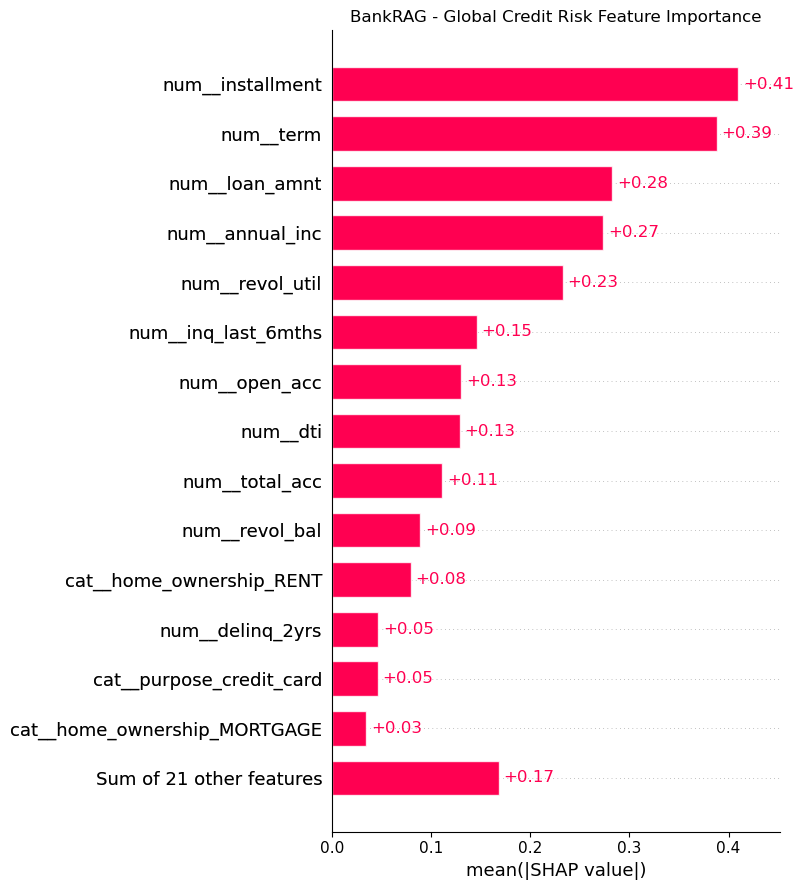

In [ ]:
# ---------------------------------------------------------
# PHASE 2 - Step 2
# Global SHAP Feature Importance
# ---------------------------------------------------------

import matplotlib.pyplot as plt


shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "CredWise AI - Global Credit Risk Feature Importance"
)

plt.tight_layout()
plt.show()

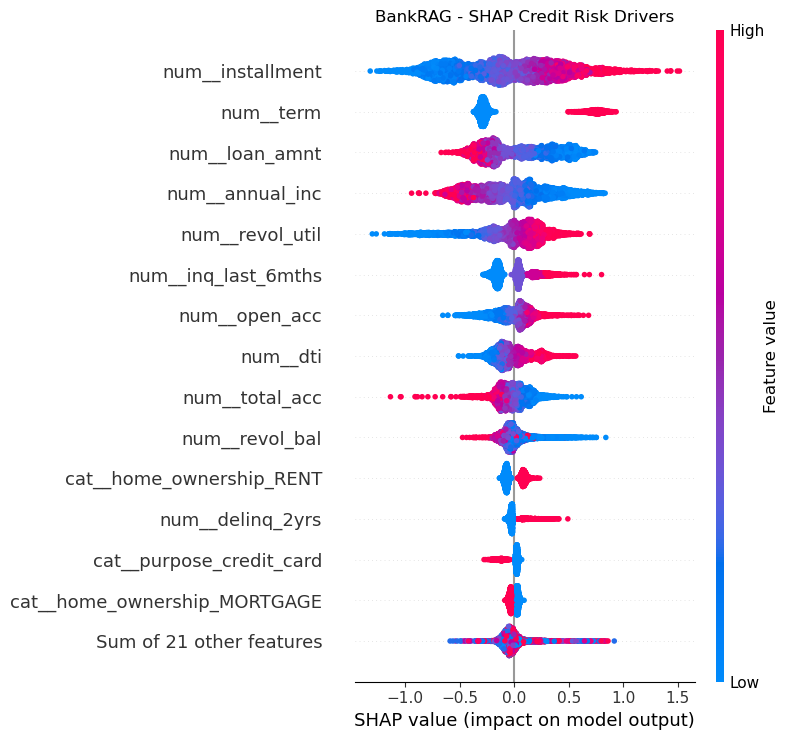

In [ ]:
# ---------------------------------------------------------
# SHAP Beeswarm Plot
# Direction + Importance
# ---------------------------------------------------------

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "CredWise AI - SHAP Credit Risk Drivers"
)

plt.tight_layout()
plt.show()

In [102]:
# ---------------------------------------------------------
# Global SHAP Importance Table
# ---------------------------------------------------------

import numpy as np
import pandas as pd


mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)


shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
})


shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 GLOBAL CREDIT RISK FEATURES")
print("=" * 60)

print(
    shap_importance_df
    .head(15)
    .round(4)
    .to_string(index=False)
)

TOP 15 GLOBAL CREDIT RISK FEATURES
                     Feature  Mean_Abs_SHAP
            num__installment         0.4098
                   num__term         0.3879
              num__loan_amnt         0.2827
             num__annual_inc         0.2737
             num__revol_util         0.2329
         num__inq_last_6mths         0.1461
               num__open_acc         0.1305
                    num__dti         0.1289
              num__total_acc         0.1112
              num__revol_bal         0.0892
    cat__home_ownership_RENT         0.0797
            num__delinq_2yrs         0.0467
    cat__purpose_credit_card         0.0461
cat__home_ownership_MORTGAGE         0.0346
             num__emp_length         0.0313


In [103]:
# ---------------------------------------------------------
# PHASE 2 - Step 3
# Select an individual high-risk borrower
# ---------------------------------------------------------

# Get raw XGBoost scores for our 5,000 SHAP borrowers
shap_raw_scores = xgb_pipeline.predict_proba(
    X_shap_raw
)[:, 1]


# Select borrower with highest raw risk score
borrower_position = np.argmax(
    shap_raw_scores
)


# Original borrower data
borrower = X_shap_raw.iloc[
    borrower_position
]


# Raw XGBoost score
borrower_raw_score = shap_raw_scores[
    borrower_position
]


# Calibrated Probability of Default
borrower_pd = calibrator.predict(
    [borrower_raw_score]
)[0]


print("=" * 60)
print("SELECTED BORROWER")
print("=" * 60)

print("\nOriginal applicant information:")
print(borrower)

print("\nRaw XGBoost risk score:")
print(f"{borrower_raw_score:.4f}")

print("\nCalibrated Probability of Default:")
print(f"{borrower_pd:.2%}")

SELECTED BORROWER

Original applicant information:
loan_amnt                      16000.0
term                                60
installment                     357.78
emp_length                          10
home_ownership                     OWN
annual_inc                     40000.0
verification_status    Source Verified
purpose                 small_business
dti                               8.88
delinq_2yrs                        0.0
inq_last_6mths                     7.0
open_acc                           6.0
pub_rec                            0.0
revol_bal                     102318.0
revol_util                        15.3
total_acc                         13.0
Name: 24117, dtype: object

Raw XGBoost risk score:
0.9306

Calibrated Probability of Default:
100.00%


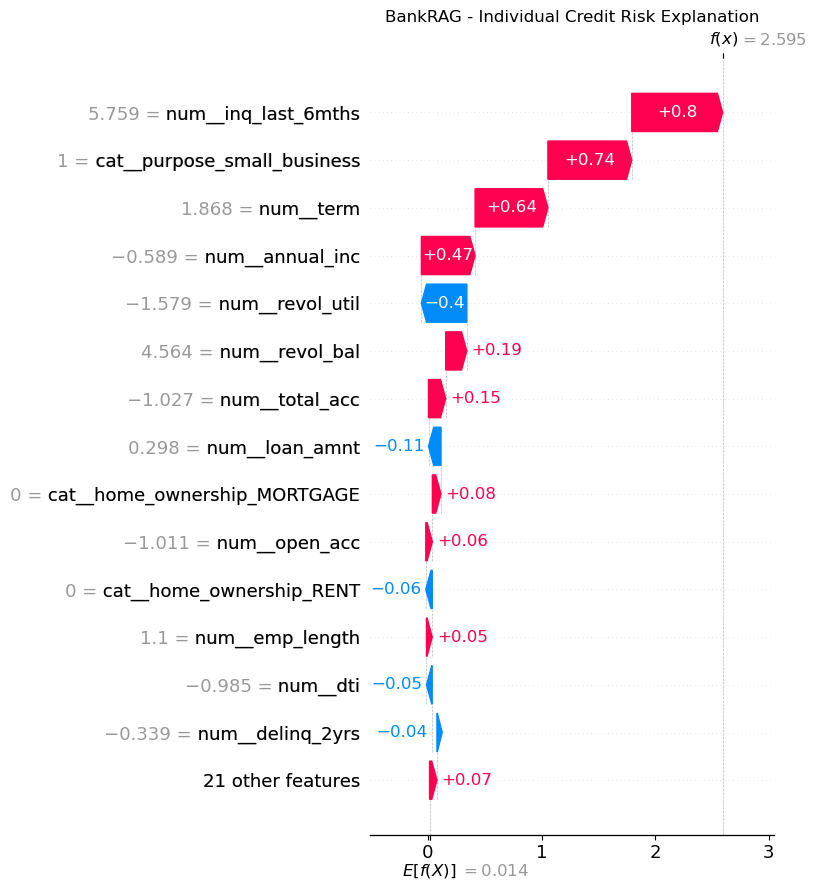

In [ ]:
# ---------------------------------------------------------
# Individual Borrower SHAP Waterfall Plot
# ---------------------------------------------------------

borrower_shap = shap_values[
    borrower_position
]


shap.plots.waterfall(
    borrower_shap,
    max_display=15,
    show=False
)


plt.title(
    "CredWise AI - Individual Credit Risk Explanation"
)

plt.tight_layout()
plt.show()

In [105]:
# ---------------------------------------------------------
# Extract Individual Borrower SHAP Contributions
# ---------------------------------------------------------

borrower_contributions = pd.DataFrame({

    "Feature": feature_names,

    "SHAP_Value": borrower_shap.values,

    "Abs_SHAP": np.abs(
        borrower_shap.values
    )
})


borrower_contributions = (
    borrower_contributions
    .sort_values(
        by="Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 10 FACTORS FOR THIS BORROWER")
print("=" * 65)

print(
    borrower_contributions
    .head(10)
    .round(4)
    .to_string(index=False)
)

TOP 10 FACTORS FOR THIS BORROWER
                     Feature  SHAP_Value  Abs_SHAP
         num__inq_last_6mths      0.8003    0.8003
 cat__purpose_small_business      0.7385    0.7385
                   num__term      0.6412    0.6412
             num__annual_inc      0.4733    0.4733
             num__revol_util     -0.4000    0.4000
              num__revol_bal      0.1855    0.1855
              num__total_acc      0.1516    0.1516
              num__loan_amnt     -0.1096    0.1096
cat__home_ownership_MORTGAGE      0.0758    0.0758
               num__open_acc      0.0577    0.0577


In [106]:
# ---------------------------------------------------------
# PHASE 2 - Step 4
# Human-readable feature names
# ---------------------------------------------------------

feature_label_map = {

    "num__loan_amnt":
        "Loan Amount",

    "num__term":
        "Loan Term",

    "num__emp_length":
        "Employment Length",

    "num__annual_inc":
        "Annual Income",

    "num__dti":
        "Debt-to-Income Ratio",

    "num__delinq_2yrs":
        "Past Delinquencies",

    "num__inq_last_6mths":
        "Recent Credit Inquiries",

    "num__open_acc":
        "Open Credit Accounts",

    "num__revol_bal":
        "Revolving Credit Balance",

    "num__revol_util":
        "Revolving Credit Utilization",

    "num__total_acc":
        "Total Credit Accounts"
}


def clean_feature_name(feature):

    # Numerical feature
    if feature in feature_label_map:
        return feature_label_map[feature]

    # Home ownership
    if feature.startswith(
        "cat__home_ownership_"
    ):

        value = feature.replace(
            "cat__home_ownership_",
            ""
        )

        return (
            "Home Ownership: "
            + value.replace("_", " ").title()
        )

    # Loan purpose
    if feature.startswith(
        "cat__purpose_"
    ):

        value = feature.replace(
            "cat__purpose_",
            ""
        )

        return (
            "Loan Purpose: "
            + value.replace("_", " ").title()
        )

    # Verification status
    if feature.startswith(
        "cat__verification_status_"
    ):

        value = feature.replace(
            "cat__verification_status_",
            ""
        )

        return (
            "Income Verification: "
            + value.replace("_", " ").title()
        )

    return (
        feature
        .replace("num__", "")
        .replace("cat__", "")
        .replace("_", " ")
        .title()
    )

In [107]:
# ---------------------------------------------------------
# Generate SHAP Reason Codes
# ---------------------------------------------------------

def generate_reason_codes(
    shap_explanation,
    feature_names,
    top_n=5
):

    reason_df = pd.DataFrame({

        "Feature": feature_names,

        "SHAP_Value":
            shap_explanation.values

    })


    reason_df["Abs_SHAP"] = np.abs(
        reason_df["SHAP_Value"]
    )


    reason_df = reason_df.sort_values(
        "Abs_SHAP",
        ascending=False
    )


    # Factors increasing default-risk score
    risk_factors = (
        reason_df[
            reason_df["SHAP_Value"] > 0
        ]
        .head(top_n)
        .copy()
    )


    # Factors decreasing default-risk score
    protective_factors = (
        reason_df[
            reason_df["SHAP_Value"] < 0
        ]
        .head(top_n)
        .copy()
    )


    risk_factors["Reason"] = (
        risk_factors["Feature"]
        .apply(clean_feature_name)
    )


    protective_factors["Reason"] = (
        protective_factors["Feature"]
        .apply(clean_feature_name)
    )


    return (
        risk_factors,
        protective_factors
    )

In [ ]:
# ---------------------------------------------------------
# Generate reason codes for selected borrower
# ---------------------------------------------------------

risk_factors, protective_factors = (
    generate_reason_codes(
        borrower_shap,
        feature_names,
        top_n=5
    )
)


print("=" * 60)
print("CredWise AI EXPLAINABLE CREDIT RISK REPORT")
print("=" * 60)

print(
    f"\nCalibrated Probability of Default: "
    f"{borrower_pd:.2%}"
)


print("\nTOP RISK-RAISING FACTORS")
print("-" * 40)

for i in range(len(risk_factors)):

    row = risk_factors.iloc[i]

    print(
        f"{i + 1}. "
        f"{row['Reason']} "
        f"(SHAP: +{row['SHAP_Value']:.4f})"
    )


print("\nTOP RISK-REDUCING FACTORS")
print("-" * 40)

for i in range(len(protective_factors)):

    row = protective_factors.iloc[i]

    print(
        f"{i + 1}. "
        f"{row['Reason']} "
        f"(SHAP: {row['SHAP_Value']:.4f})"
    )

BANKRAG EXPLAINABLE CREDIT RISK REPORT

Calibrated Probability of Default: 100.00%

TOP RISK-RAISING FACTORS
----------------------------------------
1. Recent Credit Inquiries (SHAP: +0.8003)
2. Loan Purpose: Small Business (SHAP: +0.7385)
3. Loan Term (SHAP: +0.6412)
4. Annual Income (SHAP: +0.4733)
5. Revolving Credit Balance (SHAP: +0.1855)

TOP RISK-REDUCING FACTORS
----------------------------------------
1. Revolving Credit Utilization (SHAP: -0.4000)
2. Loan Amount (SHAP: -0.1096)
3. Home Ownership: Rent (SHAP: -0.0567)
4. Debt-to-Income Ratio (SHAP: -0.0500)
5. Past Delinquencies (SHAP: -0.0423)


In [109]:
# ---------------------------------------------------------
# PHASE 3 - Banking Policy RAG
# Load Lending Policy
# ---------------------------------------------------------

from pathlib import Path


policy_path = Path("../rag/lending_policy.txt")

# If notebook is running from project root instead
if not policy_path.exists():
    policy_path = Path("rag/lending_policy.txt")


with open(
    policy_path,
    "r",
    encoding="utf-8"
) as file:

    policy_text = file.read()


print("Policy loaded successfully.")
print("Characters:", len(policy_text))

print("\nPreview:")
print(policy_text[:500])

Policy loaded successfully.
Characters: 2687

Preview:
BANKRAG LENDING POLICY KNOWLEDGE BASE

SECTION: DEBT-TO-INCOME RATIO

Debt-to-income ratio (DTI) measures the relationship between a borrower's
monthly debt obligations and income. Higher DTI values may indicate greater
repayment burden and should receive additional credit-risk review.

Applications with elevated DTI should be assessed together with income,
loan amount, employment history, and existing credit obligations.


SECTION: CREDIT UTILIZATION

Revolving credit utilization represents the


In [110]:
# ---------------------------------------------------------
# Split policy into RAG chunks
# ---------------------------------------------------------

from langchain_text_splitters import RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100
)


chunks = text_splitter.create_documents(
    [policy_text]
)


print("Number of policy chunks:", len(chunks))

print("\nExample chunk:")
print(chunks[0].page_content)

Number of policy chunks: 5

Example chunk:
BANKRAG LENDING POLICY KNOWLEDGE BASE

SECTION: DEBT-TO-INCOME RATIO

Debt-to-income ratio (DTI) measures the relationship between a borrower's
monthly debt obligations and income. Higher DTI values may indicate greater
repayment burden and should receive additional credit-risk review.

Applications with elevated DTI should be assessed together with income,
loan amount, employment history, and existing credit obligations.


SECTION: CREDIT UTILIZATION

Revolving credit utilization represents the proportion of available revolving
credit currently being used. Elevated utilization may indicate financial
pressure and can contribute to increased credit risk.


In [111]:
# ---------------------------------------------------------
# Create Embedding Model
# ---------------------------------------------------------

from langchain_community.embeddings import HuggingFaceEmbeddings


embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


print("Embedding model loaded successfully.")

C:\Users\tiwar\AppData\Local\Temp\ipykernel_27392\2666415840.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
C:\Users\tiwar\AppData\Local\Temp\ipykernel_27392\2666415840.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\tiwar\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tiwar\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully.


In [112]:
# ---------------------------------------------------------
# Create FAISS Vector Database
# ---------------------------------------------------------

from langchain_community.vectorstores import FAISS


vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)


print("FAISS vector store created successfully.")
print("Number of stored chunks:", vector_store.index.ntotal)

FAISS vector store created successfully.
Number of stored chunks: 5


In [113]:
# ---------------------------------------------------------
# PHASE 3 - Step 4
# Retrieve Relevant Lending Policy
# ---------------------------------------------------------

def retrieve_policy(query, k=2):

    documents = vector_store.similarity_search(
        query,
        k=k
    )

    return documents

In [ ]:
# ---------------------------------------------------------
# Test Banking Policy Retrieval
# ---------------------------------------------------------

test_query = (
    "The borrower has many recent credit inquiries "
    "and high debt obligations. What policy is relevant?"
)


retrieved_docs = retrieve_policy(
    test_query,
    k=2
)


print("=" * 60)
print("CredWise AI - RETRIEVED POLICY EVIDENCE")
print("=" * 60)


for i in range(len(retrieved_docs)):

    print(f"\nPOLICY CHUNK {i + 1}")
    print("-" * 40)

    print(
        retrieved_docs[i].page_content
    )

BANKRAG - RETRIEVED POLICY EVIDENCE

POLICY CHUNK 1
----------------------------------------
Credit utilization should not be used as the sole basis for a lending decision.


SECTION: CREDIT INQUIRIES

Multiple recent credit inquiries may indicate that a borrower is seeking
additional credit obligations.

A high number of recent inquiries should trigger additional review together
with the applicant's income, debt obligations, and overall credit profile.


SECTION: DELINQUENCY HISTORY

Previous delinquencies may indicate difficulty meeting past credit obligations.

Recent or repeated delinquencies should receive additional risk review.
Delinquency history should be evaluated together with the applicant's broader
credit profile.


SECTION: INCOME AND REPAYMENT CAPACITY

POLICY CHUNK 2
----------------------------------------
SECTION: EMPLOYMENT HISTORY

Employment history can provide information about income stability.

Short employment history may require additional review but should no

In [115]:
# ---------------------------------------------------------
# PHASE 4 - Grounded LLM Explanation
# Test Ollama Connection
# ---------------------------------------------------------

import ollama


response = ollama.chat(
    model="llama3.2",
    messages=[
        {
            "role": "user",
            "content": "Reply only with: BankRAG LLM connected successfully."
        }
    ]
)


print(response["message"]["content"])

BankRAG LLM connected successfully.


In [ ]:
# ---------------------------------------------------------
# PHASE 4 - Build Grounded LLM Context
# ---------------------------------------------------------

# Convert SHAP risk factors into readable text
risk_reason_text = "\n".join(
    [
        f"- {row['Reason']}"
        for _, row in risk_factors.iterrows()
    ]
)


# Convert protective factors into readable text
protective_reason_text = "\n".join(
    [
        f"- {row['Reason']}"
        for _, row in protective_factors.iterrows()
    ]
)


# Create RAG query using the borrower's main risk factors
rag_query = (
    "Lending policy related to: "
    + ", ".join(
        risk_factors["Reason"].tolist()
    )
)


# Retrieve the two most relevant policy chunks
policy_docs = retrieve_policy(
    rag_query,
    k=2
)


# Combine retrieved chunks
policy_context = "\n\n".join(
    [
        doc.page_content
        for doc in policy_docs
    ]
)


print("=" * 60)
print("CredWise AI LLM CONTEXT")
print("=" * 60)

print("\nProbability of Default:")
print(f"{borrower_pd:.2%}")

print("\nRisk-Raising Factors:")
print(risk_reason_text)

print("\nRisk-Reducing Factors:")
print(protective_reason_text)

print("\nRAG Query:")
print(rag_query)

print("\nRetrieved Policy Evidence:")
print(policy_context)

BANKRAG LLM CONTEXT

Probability of Default:
100.00%

Risk-Raising Factors:
- Recent Credit Inquiries
- Loan Purpose: Small Business
- Loan Term
- Annual Income
- Revolving Credit Balance

Risk-Reducing Factors:
- Revolving Credit Utilization
- Loan Amount
- Home Ownership: Rent
- Debt-to-Income Ratio
- Past Delinquencies

RAG Query:
Lending policy related to: Recent Credit Inquiries, Loan Purpose: Small Business, Loan Term, Annual Income, Revolving Credit Balance

Retrieved Policy Evidence:
SECTION: EMPLOYMENT HISTORY

Employment history can provide information about income stability.

Short employment history may require additional review but should not by
itself determine loan eligibility.


SECTION: LOAN TERM

Longer repayment terms may reduce monthly payment burden but extend the period
of credit exposure.

Loan term should therefore be evaluated together with loan amount,
installment size, income, and overall borrower risk.


SECTION: DECISION POLICY

Credit-risk predictions are 

In [ ]:
# ---------------------------------------------------------
# PHASE 4 - Generate Grounded Credit Risk Report
# ---------------------------------------------------------

def generate_credit_risk_report(
    probability,
    risk_text,
    protective_text,
    policy_text
):

    prompt = f"""
You are CredWise AI, an AI credit-risk decision-support assistant.

Generate a concise and professional credit-risk explanation using ONLY
the information provided below.

RULES:
- Do not invent borrower information.
- Do not invent lending policies.
- Do not approve or reject the loan.
- Treat the model output as decision support only.
- Clearly distinguish model risk factors from policy evidence.
- Recommend human review when appropriate.

ESTIMATED PROBABILITY OF DEFAULT:
{probability:.2%}

MODEL RISK-RAISING FACTORS:
{risk_text}

MODEL RISK-REDUCING FACTORS:
{protective_text}

RETRIEVED LENDING POLICY:
{policy_text}

Return exactly these sections:

1. Risk Assessment
2. Key Risk Drivers
3. Protective Factors
4. Relevant Policy Considerations
5. Human Review Recommendation
"""


    response = ollama.chat(
        model="llama3.2",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )


    return response["message"]["content"]

In [ ]:
# ---------------------------------------------------------
# Test Complete CredWise AI Explanation
# ---------------------------------------------------------

final_report = generate_credit_risk_report(
    probability=borrower_pd,
    risk_text=risk_reason_text,
    protective_text=protective_reason_text,
    policy_text=policy_context
)


print("=" * 70)
print("CredWise AI - AI CREDIT RISK REPORT")
print("=" * 70)

print(final_report)

BANKRAG - AI CREDIT RISK REPORT
**Risk Assessment**

The estimated probability of default is 100.00%, indicating a high credit-risk profile.

**Key Risk Drivers**

Recent Credit Inquiries, Loan Purpose: Small Business, Revolving Credit Balance, and Annual Income are model risk-raising factors that contribute to the high credit-risk profile.

Revolving Credit Utilization, Loan Amount, Home Ownership: Rent, Debt-to-Income Ratio, and Past Delinquencies are model risk-reducing factors that mitigate some of the credit-risk concerns.

**Protective Factors**

The Revolving Credit Utilization and Loan Amount appear to be protective factors as they may indicate a larger available credit cushion or a more manageable monthly payment burden.

**Relevant Policy Considerations**

Policy sections on Employment History, Loan Term, Decision Policy, Credit Inquiries, Delinquency History, and Income & Repayment Capacity are relevant in evaluating the applicant's overall risk profile.

**Human Review Reco

In [ ]:
print("CredWise AI model input features:")
print("=" * 40)

for i in range(len(X_train.columns)):
    print(f"{i + 1}. {X_train.columns[i]}")

print("\nTotal:", len(X_train.columns))

BankRAG model input features:
1. loan_amnt
2. term
3. installment
4. emp_length
5. home_ownership
6. annual_inc
7. verification_status
8. purpose
9. dti
10. delinq_2yrs
11. inq_last_6mths
12. open_acc
13. pub_rec
14. revol_bal
15. revol_util
16. total_acc

Total: 16


In [ ]:
# =========================================================
# Save CredWise AI XGBoost production pipeline
# =========================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_pipeline,
    "../models/xgboost_pipeline.pkl"
)

print("XGBoost pipeline saved successfully.")
print("Saved at: ../models/xgboost_pipeline.pkl")

XGBoost pipeline saved successfully.
Saved at: ../models/xgboost_pipeline.pkl


In [ ]:
# =========================================================
# Save CredWise AI probability calibrator
# =========================================================

import joblib

joblib.dump(
    calibrator,
    "../models/probability_calibrator.pkl"
)

print("Probability calibrator saved successfully.")

Probability calibrator saved successfully.


In [125]:
# =========================================================
# Check available SHAP objects
# =========================================================

shap_objects = [
    name for name in globals()
    if "shap" in name.lower() or "explainer" in name.lower()
]

print("Available SHAP-related objects:")
print(shap_objects)

Available SHAP-related objects:
['shap', 'X_shap_raw', 'X_shap_processed', 'explainer', 'shap_values', 'mean_abs_shap', 'shap_importance_df', 'shap_raw_scores', 'borrower_shap']


In [ ]:
# =========================================================
# Save SHAP explainer for CredWise AI Streamlit application
# =========================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP explainer saved successfully.")
print("Saved to: ../models/shap_explainer.pkl")

SHAP explainer saved successfully.
Saved to: ../models/shap_explainer.pkl


In [127]:
# =========================================================
# Check existing FAISS / vector-store objects
# =========================================================

vector_objects = [
    name for name in globals()
    if (
        "faiss" in name.lower()
        or "vector" in name.lower()
        or "store" in name.lower()
    )
]

print("Available FAISS / vector-store objects:")
print(vector_objects)

Available FAISS / vector-store objects:
['FAISS', 'vector_store']


In [ ]:
# =========================================================
# Save CredWise AI FAISS Policy Vector Store
# =========================================================

import os

os.makedirs("../faiss_index", exist_ok=True)

vector_store.save_local(
    "../faiss_index"
)

print("FAISS vector store saved successfully.")
print("Saved to: ../faiss_index")

FAISS vector store saved successfully.
Saved to: ../faiss_index


In [129]:
# Check saved FAISS index dimension
print("FAISS index dimension:", vector_store.index.d)

# Check embedding object stored with vector store
print("Embedding object:")
print(vector_store.embedding_function)

FAISS index dimension: 384
Embedding object:
client=SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
) model_name='sentence-transformers/all-MiniLM-L6-v2' cache_folder=None model_kwargs={} encode_kwargs={} multi_process=False show_progress=False


In [130]:
# Test current embedding dimension
test_embedding = vector_store.embedding_function.embed_query(
    "credit risk test"
)

print("Current embedding dimension:", len(test_embedding))

Current embedding dimension: 384


In [ ]:
# =========================================================
# CredWise AI - Simple RAG Retrieval Evaluation
# =========================================================

test_queries = [
    "What policy applies to high debt-to-income ratio?",
    "What policy applies to high revolving credit utilization?",
    "How should recent credit inquiries be considered?",
    "How should employment history affect credit review?",
    "What factors should be considered for loan amount and repayment burden?"
]

for i in range(len(test_queries)):

    query = test_queries[i]

    docs = vector_store.similarity_search(
        query,
        k=1
    )

    print("=" * 70)
    print("QUERY:", query)
    print("\nTOP RETRIEVED POLICY:")
    print(docs[0].page_content[:500])
    print()

QUERY: What policy applies to high debt-to-income ratio?

TOP RETRIEVED POLICY:
BANKRAG LENDING POLICY KNOWLEDGE BASE

SECTION: DEBT-TO-INCOME RATIO

Debt-to-income ratio (DTI) measures the relationship between a borrower's
monthly debt obligations and income. Higher DTI values may indicate greater
repayment burden and should receive additional credit-risk review.

Applications with elevated DTI should be assessed together with income,
loan amount, employment history, and existing credit obligations.


SECTION: CREDIT UTILIZATION

Revolving credit utilization represents the

QUERY: What policy applies to high revolving credit utilization?

TOP RETRIEVED POLICY:
Credit utilization should not be used as the sole basis for a lending decision.


SECTION: CREDIT INQUIRIES

Multiple recent credit inquiries may indicate that a borrower is seeking
additional credit obligations.

A high number of recent inquiries should trigger additional review together
with the applicant's income, debt obliga